In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import statistics
import math
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import pandas as pd
import matplotlib as mpl
from sklearn.cluster import KMeans
from tabulate import tabulate

In [2]:
Nor1Up1NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor1/NoCC/Updraft1/interp_nn_timeseries.nc')
Nor2Up1NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor2/NoCC/Updraft1/interp_nn_timeseries.nc')
Nor3Up1NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor3/NoCC/Updraft1/interp_nn_timeseries.nc')
Nor4Up1NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor4/NoCC/Updraft1/interp_nn_timeseries.nc')
Nor1Up2NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor1/NoCC/Updraft2/interp_nn_timeseries.nc')
Nor2Up2NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor2/NoCC/Updraft2/interp_nn_timeseries.nc')
Nor3Up2NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor3/NoCC/Updraft2/interp_nn_timeseries.nc')
Nor4Up2NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor4/NoCC/Updraft2/interp_nn_timeseries.nc')
Nor1Up3NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor1/NoCC/Updraft3/interp_nn_timeseries.nc')
Nor2Up3NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor2/NoCC/Updraft3/interp_nn_timeseries.nc')
Nor3Up3NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor3/NoCC/Updraft3/interp_nn_timeseries.nc')
Nor4Up3NoCC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor4/NoCC/Updraft3/interp_nn_timeseries.nc')

In [3]:
Nor1Up1CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor1/CC/Updraft1/interp_nn_timeseries.nc')
Nor2Up1CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor2/CC/Updraft1/interp_nn_timeseries.nc')
Nor3Up1CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor3/CC/Updraft1/interp_nn_timeseries.nc')
Nor4Up1CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor4/CC/Updraft1/interp_nn_timeseries.nc')
Nor1Up2CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor1/CC/Updraft2/interp_nn_timeseries.nc')
Nor2Up2CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor2/CC/Updraft2/interp_nn_timeseries.nc')
Nor3Up2CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor3/CC/Updraft2/interp_nn_timeseries.nc')
Nor4Up2CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor4/CC/Updraft2/interp_nn_timeseries.nc')
Nor1Up3CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor1/CC/Updraft3/interp_nn_timeseries.nc')
Nor2Up3CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor2/CC/Updraft3/interp_nn_timeseries.nc')
Nor3Up3CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor3/CC/Updraft3/interp_nn_timeseries.nc')
Nor4Up3CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor4/CC/Updraft3/interp_nn_timeseries.nc')


In [4]:
Name_ls = [Nor1Up1NoCC_ds, Nor2Up1NoCC_ds,Nor3Up1NoCC_ds,Nor4Up1NoCC_ds,Nor1Up2NoCC_ds, Nor2Up2NoCC_ds,Nor3Up2NoCC_ds,Nor4Up2NoCC_ds,\
           Nor1Up3NoCC_ds,Nor2Up3NoCC_ds,Nor3Up3NoCC_ds,Nor4Up3NoCC_ds,\
Nor1Up1CC_ds, Nor2Up1CC_ds,Nor3Up1CC_ds, Nor4Up1CC_ds,Nor1Up2CC_ds, Nor2Up2CC_ds,Nor3Up2CC_ds,Nor4Up2CC_ds,\
           Nor1Up3CC_ds,Nor2Up3CC_ds,Nor3Up3CC_ds,Nor4Up3CC_ds]

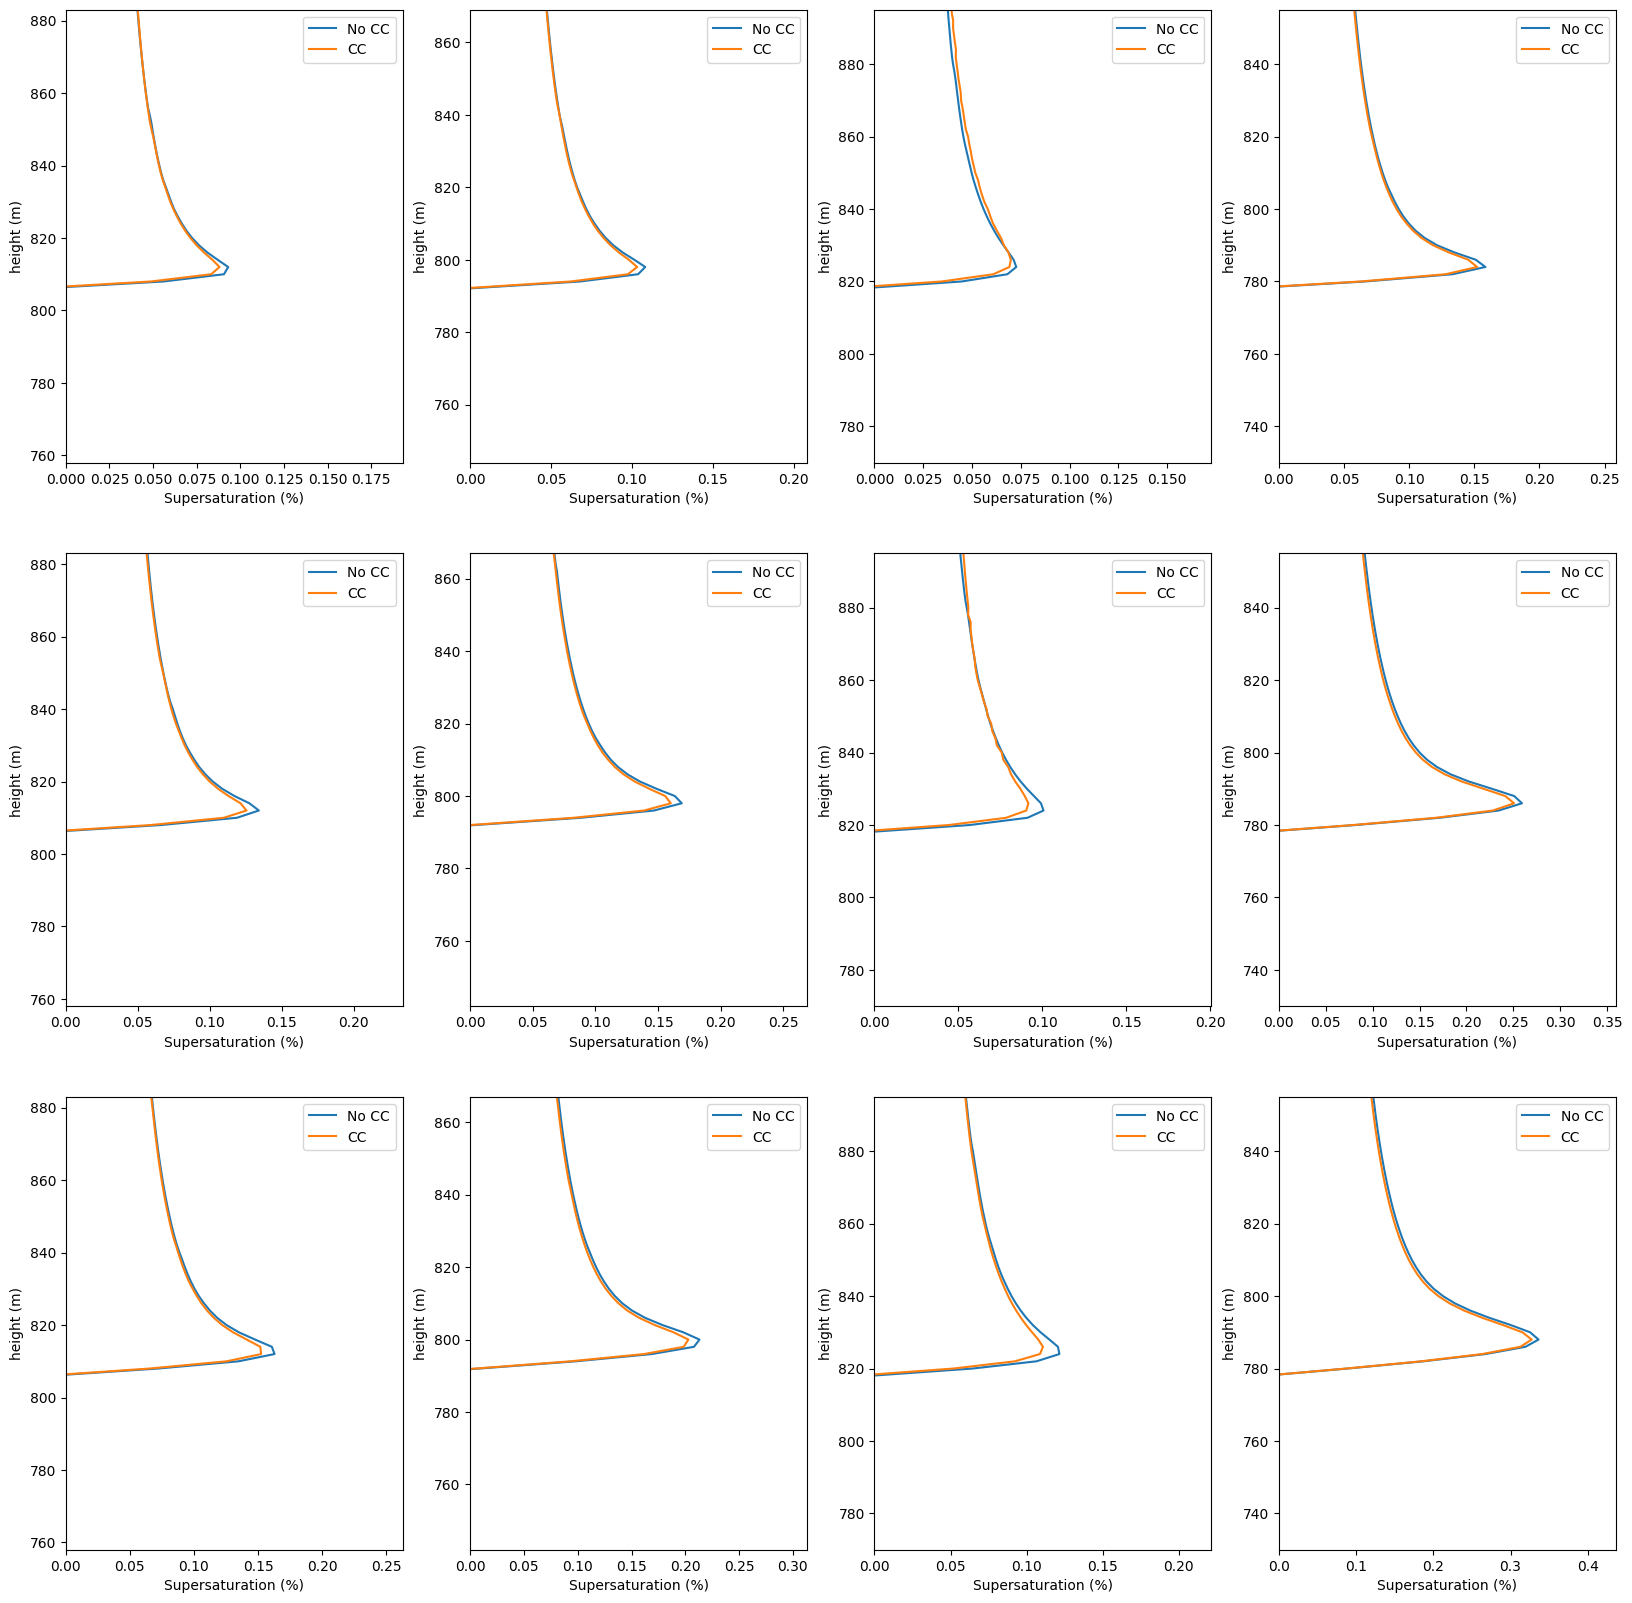

In [5]:
fig = plt.figure(figsize = (20,20))
for i in range (0,12):
    plt.subplot(3,4,i+1)
    plt.plot(Name_ls[i]['susa'],Name_ls[i]['height'], label = 'No CC')
    plt.plot(Name_ls[i+12]['susa'],Name_ls[i+12]['height'], label = 'CC')
    plt.xlim([0,Name_ls[i]['susa'].max()+.1])
    CBheight = np.min(Name_ls[i]['height'].where(Name_ls[i]['susa']>=0))
    plt.ylim([CBheight-50, CBheight+75])
    plt.ylabel('height (m)')
    plt.xlabel('Supersaturation (%)')
    plt.legend()

In [6]:
Nor1Up1CC_ds['fa_act'].isel(time_entries =-1, num_activation_criteria = 2,num_aerosols_plus_3 = 0).values

array(506.56090339)

In [7]:
Nor1Up1CC_ds['fa_act']

<xarray.DataArray 'fa_act' (time_entries: 198, num_activation_criteria: 4,
                            num_aerosols_plus_3: 7)> Size: 44kB
[5544 values with dtype=float64]
Dimensions without coordinates: time_entries, num_activation_criteria,
                                num_aerosols_plus_3
Attributes:
    units:        # cm-3
    description:  Activated cloud drop concentration. Entries 1-4: for each a...

In [8]:
Delta_SMax = []
NoCC_SMax = []
CC_SMax = []
for i in range (0, int(len(Name_ls)/2)):
    Delta_SMax.append(Name_ls[i]['susa'].max().values-Name_ls[i+int(len(Name_ls)/2)]['susa'].max().values)
    NoCC_SMax.append(Name_ls[i]['susa'].max().values)
    CC_SMax.append(Name_ls[i+int(len(Name_ls)/2)]['susa'].max().values)
Data = {'NoCC Smax': NoCC_SMax, 'CC Smax': CC_SMax, 'Delta SMax': Delta_SMax}
Smax_df = pd.DataFrame(Data)
Smax_df.index = ['Cluster 1 Updraft 1','Cluster 2 Updraft 1','Cluster 3 Updraft 1','Cluster 4 Updraft 1', 'Cluster 1 Updraft 2','Cluster 2 Updraft 2','Cluster 3 Updraft 2','Cluster 4 Updraft 2','Cluster 1 Updraft 3','Cluster 2 Updraft 3','Cluster 3 Updraft 3','Cluster 4 Updraft 3']
Smax_df

,NoCC Smax,CC Smax,Delta SMax
Cluster 1 Updraft 1,0.09304355493651595,0.08809494436402847,0.004949
Cluster 2 Updraft 1,0.10823814907549603,0.10324345947899255,0.004995
Cluster 3 Updraft 1,0.07264381378130039,0.0698700093976518,0.002774
Cluster 4 Updraft 1,0.15854191936483525,0.15213938389167259,0.006403
Cluster 1 Updraft 2,0.1342171953442985,0.12561346374101512,0.008604
Cluster 2 Updraft 2,0.1689343568968497,0.16015190593535067,0.008782
Cluster 3 Updraft 2,0.10068481894997972,0.09166946078200354,0.009015
Cluster 4 Updraft 2,0.25920834572366647,0.25074878806704837,0.008460
Cluster 1 Updraft 3,0.16287154425648068,0.1523822319413488,0.010489
Cluster 2 Updraft 3,0.21317056252242433,0.20286492170257067,0.010306


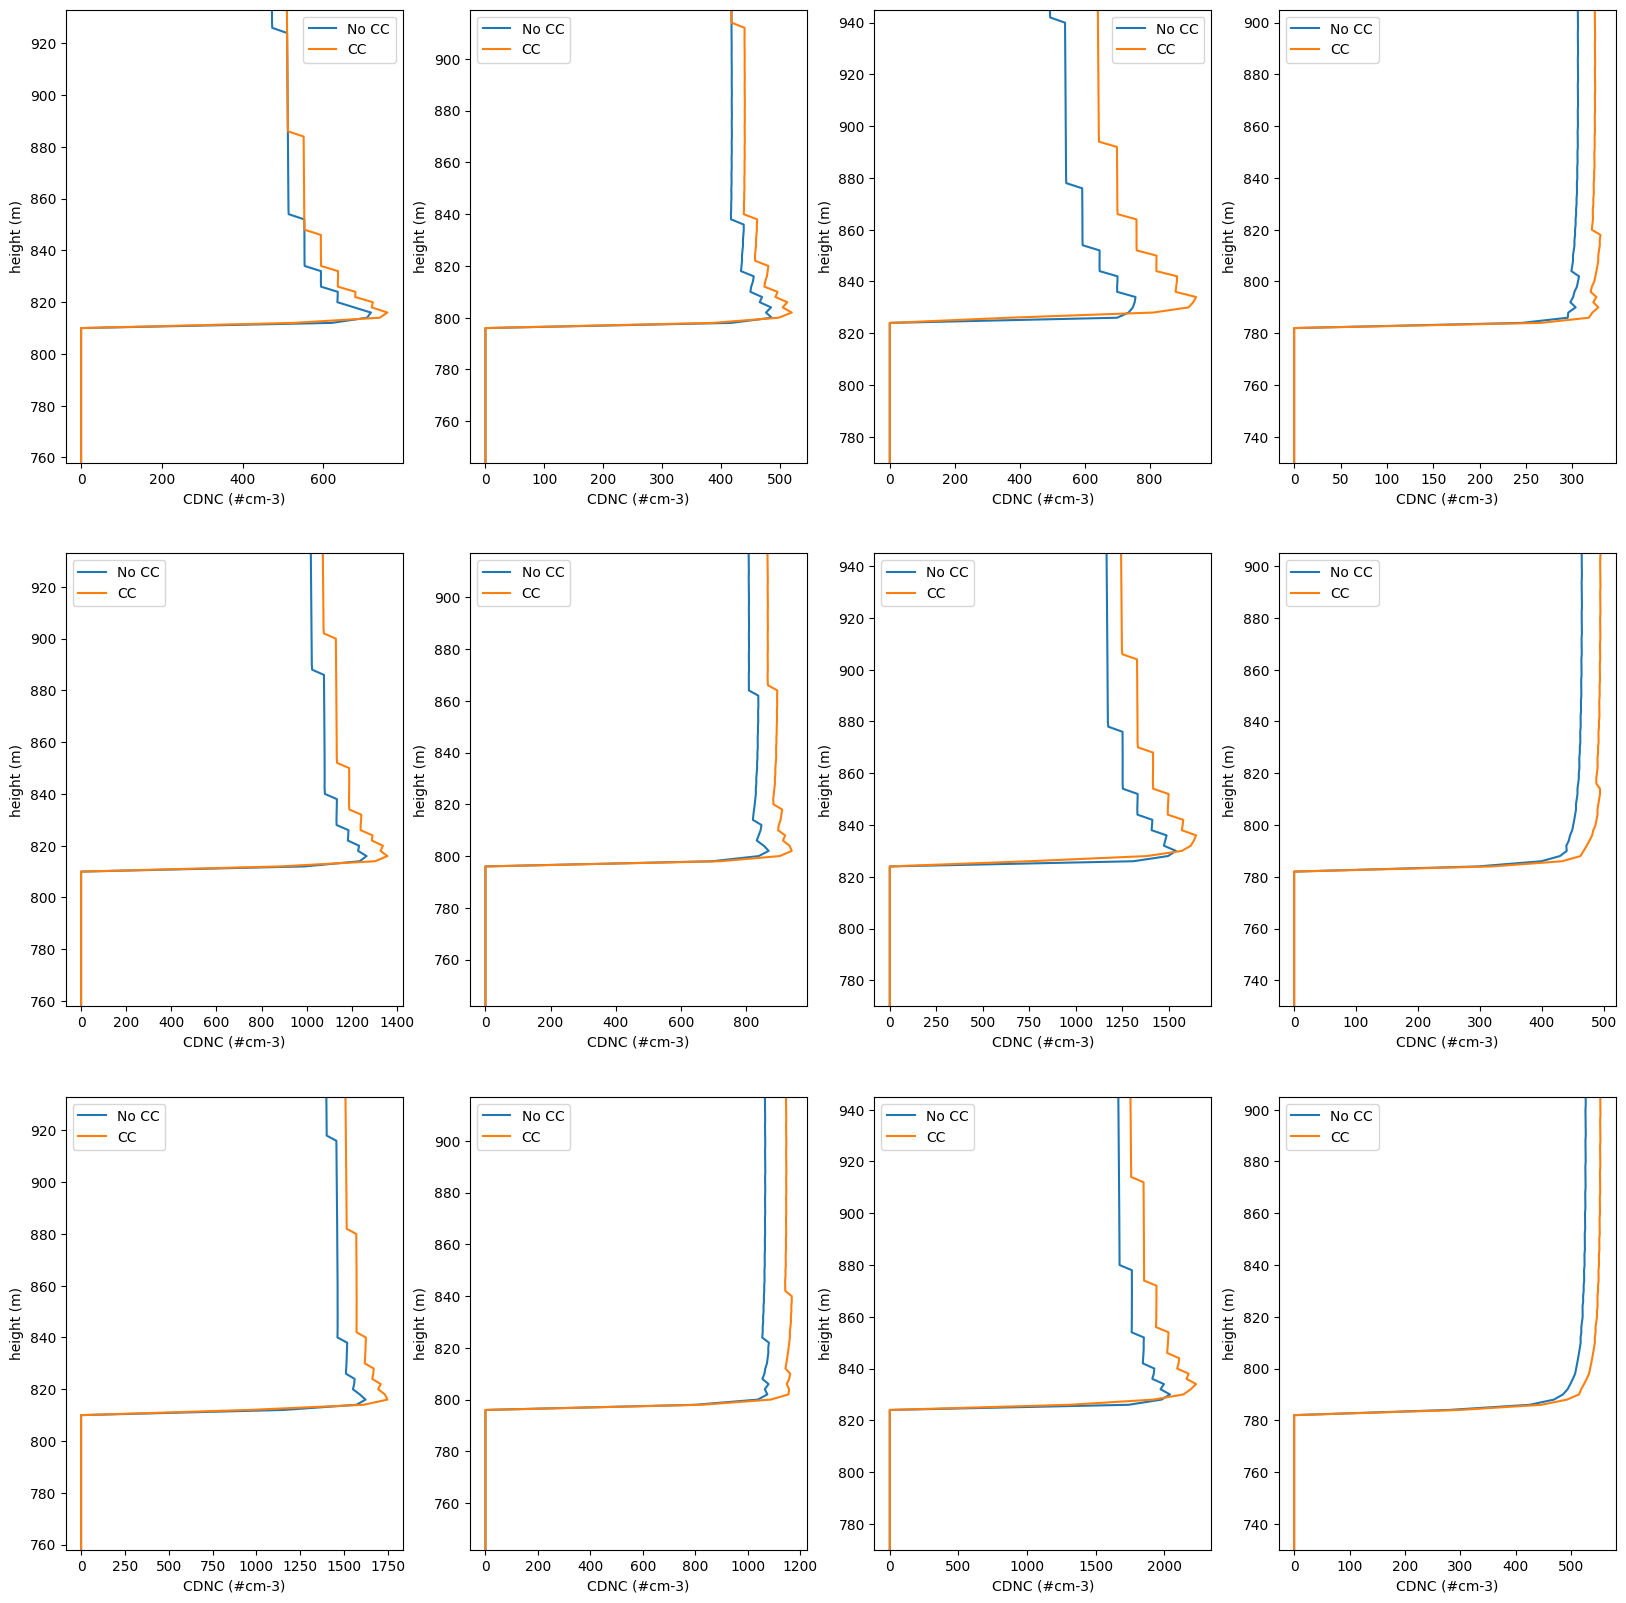

In [9]:
fig = plt.figure(figsize = (20,20))
for i in range (0,12):
    plt.subplot(3,4,i+1)
    CDNCNOCC = Name_ls[i]['fa_act'].isel( num_activation_criteria = 2,num_aerosols_plus_3 = 0)
    CDNCCC = Name_ls[i+12]['fa_act'].isel( num_activation_criteria = 2,num_aerosols_plus_3 = 0)
    plt.plot(CDNCNOCC, Name_ls[i]['height'], label = 'No CC')
    plt.plot(CDNCCC, Name_ls[i+12]['height'], label = 'CC')
    CBheight = np.min(Name_ls[i]['height'].where(Name_ls[i]['susa']>=0))
    plt.ylim([CBheight-50, CBheight+125])
    plt.ylabel('height (m)')
    plt.xlabel('CDNC (#cm-3)')
    plt.legend()

In [10]:
CDNC_df = pd.DataFrame({'NoCC CDNC ($cm^{-3}$)': np.arange(1, 13), 'CC CDNC ($cm^{-3}$)': np.random.randint(10, 100, size=12) })
for i in range (0, int(len(Name_ls)/2)):

    CBheight = np.min(Name_ls[i]['height'].where(Name_ls[i]['susa']>=0))
    CB_plus100_time = Name_ls[i]['time_entries'].where(Name_ls[i]['height'] == CBheight).dropna('time_entries').values.squeeze()+100
    if CB_plus100_time > 198:
        CDNC_df.loc[i,'NoCC CDNC ($cm^{-3}$)'] = np.int64(Name_ls[i]['fa_act'].isel(time_entries = -1, num_activation_criteria = 2,num_aerosols_plus_3 = 0).values)
        CDNC_df.loc[i,'CC CDNC ($cm^{-3}$)'] = np.int64(Name_ls[i+int(len(Name_ls)/2)]['fa_act'].isel(time_entries = -1, num_activation_criteria = 2,num_aerosols_plus_3 = 0).values)
        continue
    CDNC_df.loc[i,'NoCC CDNC ($cm^{-3}$)'] = np.int64(Name_ls[i]['fa_act'].isel(time_entries = int(CB_plus100_time), num_activation_criteria = 2,num_aerosols_plus_3 = 0).values)
    CDNC_df.loc[i,'CC CDNC ($cm^{-3}$)'] = np.int64(Name_ls[i+int(len(Name_ls)/2)]['fa_act'].isel(time_entries = int(CB_plus100_time), num_activation_criteria = 2,num_aerosols_plus_3 = 0).values)
    

CDNC_df["Percentage_Increase"] = ((CDNC_df["CC CDNC ($cm^{-3}$)"] - CDNC_df["NoCC CDNC ($cm^{-3}$)"]) / CDNC_df["NoCC CDNC ($cm^{-3}$)"]) * 100

CDNCUpdraft1_df = CDNC_df.iloc[:4]  
CDNCUpdraft2_df = CDNC_df.iloc[4:8]  
CDNCUpdraft3_df = CDNC_df.iloc[8:12] 
CDNC_df.index = ['Cluster 1 Updraft 1','Cluster 2 Updraft 1','Cluster 3 Updraft 1','Cluster 4 Updraft 1', 'Cluster 1 Updraft 2','Cluster 2 Updraft 2','Cluster 3 Updraft 2','Cluster 4 Updraft 2','Cluster 1 Updraft 3','Cluster 2 Updraft 3','Cluster 3 Updraft 3','Cluster 4 Updraft 3']

In [41]:
CDNC_df_2 = pd.DataFrame({'NoCC CDNC ($cm^{-3}$)': np.arange(1, 13), 'CC CDNC ($cm^{-3}$)': np.random.randint(10, 100, size=12) })

for i in range(0, int(len(Name_ls)/2)):

    # Get cloud base height
    CBheight = np.min(Name_ls[i]['time_entries'].where(Name_ls[i]['susa'] >= 0))
    # Get time at CB + 100s
    CB_plus100_time = Name_ls[i]['time_entries'].where(
        Name_ls[i]['height'] == CBheight
    ).dropna('time_entries').values.squeeze() + 100

    NoCC_data = Name_ls[i]['fa_act'].sel(
        num_activation_criteria=2,
        num_aerosols_plus_3=0
    )

    CC_data = Name_ls[i + int(len(Name_ls)/2)]['fa_act'].sel(
        num_activation_criteria=2,
        num_aerosols_plus_3=0
    )


    # Only take values where height > CBheight
    height_mask_NoCC = Name_ls[i]['time_entries'] > CBheight
    height_mask_CC = Name_ls[i + int(len(Name_ls)/2)]['time_entries'] > CBheight

    # Median fa_act above cloud base
    CDNC_df_2.loc[i, 'NoCC CDNC ($cm^{-3}$)'] = np.median(NoCC_data.where(height_mask_NoCC, drop=True).values)
    CDNC_df_2.loc[i, 'CC CDNC ($cm^{-3}$)'] = np.median(CC_data.where(height_mask_CC, drop=True).values)
CDNC_df_2["Percentage_Increase"] = ((CDNC_df_2["CC CDNC ($cm^{-3}$)"] - CDNC_df_2["NoCC CDNC ($cm^{-3}$)"]) / CDNC_df_2["NoCC CDNC ($cm^{-3}$)"]) * 100

CDNCUpdraft1_df = CDNC_df_2.iloc[:4]  
CDNCUpdraft2_df = CDNC_df_2.iloc[4:8]  
CDNCUpdraft3_df = CDNC_df_2.iloc[8:12] 
CDNC_df_2.index = ['Cluster 1 Updraft 1','Cluster 2 Updraft 1','Cluster 3 Updraft 1','Cluster 4 Updraft 1', 'Cluster 1 Updraft 2','Cluster 2 Updraft 2','Cluster 3 Updraft 2','Cluster 4 Updraft 2','Cluster 1 Updraft 3','Cluster 2 Updraft 3','Cluster 3 Updraft 3','Cluster 4 Updraft 3']

/tmp/ipykernel_1646272/3283150519.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '511.2329307489998' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  CDNC_df_2.loc[i, 'NoCC CDNC ($cm^{-3}$)'] = np.median(NoCC_data.where(height_mask_NoCC, drop=True).values)
/tmp/ipykernel_1646272/3283150519.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '511.22457196633655' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  CDNC_df_2.loc[i, 'CC CDNC ($cm^{-3}$)'] = np.median(CC_data.where(height_mask_CC, drop=True).values)


In [42]:
CDNC_df_2

,NoCC CDNC ($cm^{-3}$),CC CDNC ($cm^{-3}$),Percentage_Increase
Cluster 1 Updraft 1,511.232931,511.224572,-0.001635
Cluster 2 Updraft 1,418.256524,440.230360,5.253674
Cluster 3 Updraft 1,540.976462,642.383050,18.745102
Cluster 4 Updraft 1,305.223848,323.814852,6.090941
Cluster 1 Updraft 2,990.171705,1041.937054,5.227916
Cluster 2 Updraft 2,789.026801,845.727402,7.186144
Cluster 3 Updraft 2,1060.341336,1133.709419,6.919289
Cluster 4 Updraft 2,453.744426,483.236314,6.499669
Cluster 1 Updraft 3,1332.861710,1385.030079,3.914012
Cluster 2 Updraft 3,1020.327780,1097.326793,7.546498


In [12]:

CDNC_ds = CDNC_df.to_xarray()
!rm /share/pech2273/NorCDNCParsec.nc
CDNC_ds.to_netcdf('/share/pech2273/NorCDNCParsec.nc')


In [13]:
CDNCUpdraft1_df.index = ['Cluster 1','Cluster 2','Cluster 3','Cluster 4']
CDNCUpdraft1_df

,NoCC CDNC ($cm^{-3}$),CC CDNC ($cm^{-3}$),Percentage_Increase
Cluster 1,469,506,7.889126
Cluster 2,394,415,5.329949
Cluster 3,490,585,19.387755
Cluster 4,304,322,5.921053


In [14]:
CDNCUpdraft2_df.index = ['Cluster 1','Cluster 2','Cluster 3','Cluster 4']
CDNCUpdraft2_df

,NoCC CDNC ($cm^{-3}$),CC CDNC ($cm^{-3}$),Percentage_Increase
Cluster 1,951,951,0.000000
Cluster 2,804,862,7.213930
Cluster 3,951,1090,14.616193
Cluster 4,462,492,6.493506


In [15]:
CDNCUpdraft3_df.index = ['Cluster 1','Cluster 2','Cluster 3','Cluster 4']
CDNCUpdraft3_df

,NoCC CDNC ($cm^{-3}$),CC CDNC ($cm^{-3}$),Percentage_Increase
Cluster 1,1253,1303,3.990423
Cluster 2,1060,1140,7.547170
Cluster 3,1413,1491,5.520170
Cluster 4,524,551,5.152672


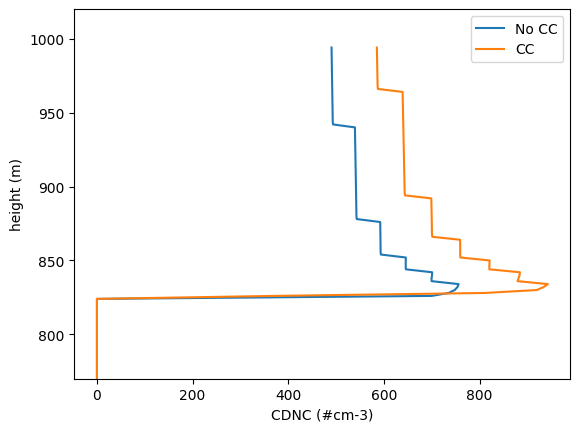

In [16]:
i = 2
CDNCNOCC = Name_ls[i]['fa_act'].isel( num_activation_criteria = 2,num_aerosols_plus_3 = 0)
CDNCCC = Name_ls[i+12]['fa_act'].isel( num_activation_criteria = 2,num_aerosols_plus_3 = 0)
plt.plot(CDNCNOCC, Name_ls[i]['height'], label = 'No CC')
plt.plot(CDNCCC, Name_ls[i+12]['height'], label = 'CC')
CBheight = np.min(Name_ls[i]['height'].where(Name_ls[i]['susa']>=0))
plt.ylim([CBheight-50, CBheight+200])
plt.ylabel('height (m)')
plt.xlabel('CDNC (#cm-3)')
plt.legend()

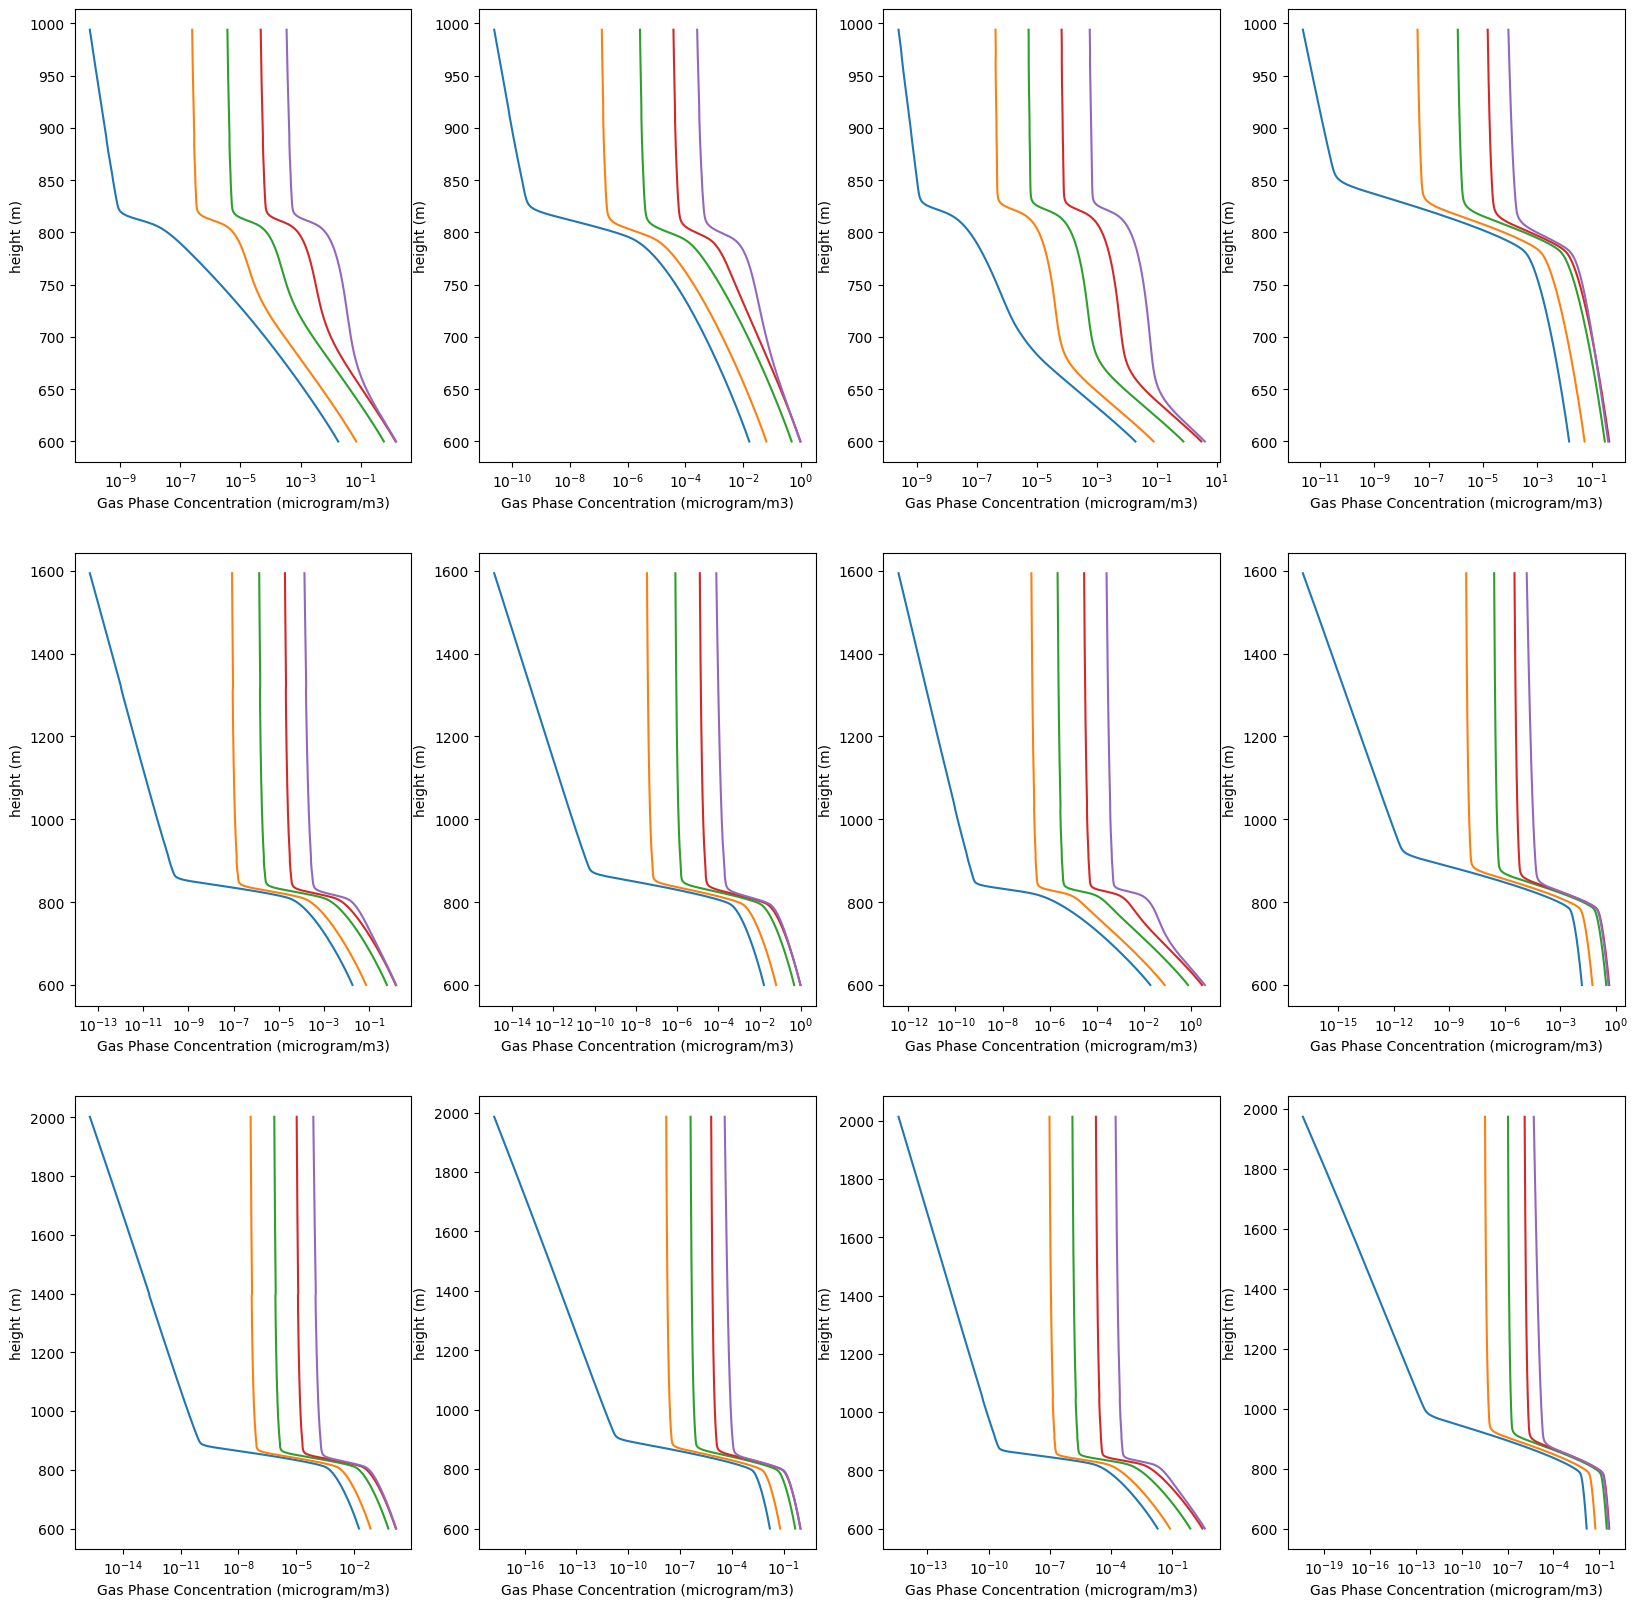

In [17]:
fig = plt.figure(figsize = (20,20))
for i in range (0,12):
    plt.subplot(3,4,i+1)
    plt.plot(Name_ls[i+12]['vbs_gas_concentration'].isel(norg_plus1 = slice(0,5))*1E9, Name_ls[i+12]['height'])
    plt.xscale('log')
    plt.xlabel('Gas Phase Concentration (microgram/m3)')
    plt.ylabel('height (m)')


In [18]:

InitialNor1Up1CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor1/CC/Updraft1/snap_time-0.nc')
InitialNor2Up1CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor2/CC/Updraft1/snap_time-0.nc')
InitialNor3Up1CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor3/CC/Updraft1/snap_time-0.nc')
InitialNor4Up1CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor4/CC/Updraft1/snap_time-0.nc')
InitialNor1Up2CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor1/CC/Updraft2/snap_time-0.nc')
InitialNor2Up2CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor2/CC/Updraft2/snap_time-0.nc')
InitialNor3Up2CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor3/CC/Updraft2/snap_time-0.nc')
InitialNor4Up2CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor4/CC/Updraft2/snap_time-0.nc')
InitialNor1Up3CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor1/CC/Updraft3/snap_time-0.nc')
InitialNor2Up3CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor2/CC/Updraft3/snap_time-0.nc')
InitialNor3Up3CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor3/CC/Updraft3/snap_time-0.nc')
InitialNor4Up3CC_ds= xr.open_dataset('/share/pech2273/PARSEC/NorESM/Nor4/CC/Updraft3/snap_time-0.nc')

In [19]:
InitialCCName_ls = [InitialNor1Up1CC_ds,InitialNor2Up1CC_ds,InitialNor3Up1CC_ds,InitialNor4Up1CC_ds,InitialNor1Up2CC_ds,InitialNor2Up2CC_ds,InitialNor3Up2CC_ds,InitialNor4Up2CC_ds,InitialNor1Up3CC_ds,InitialNor2Up3CC_ds,InitialNor3Up3CC_ds,InitialNor4Up3CC_ds,]
VBSGasConcDelta = []
for i in range(0,12):
    VBSGasConcDelta.append(sum(Name_ls[i+12]['vbs_gas_concentration'].isel(time_entries = int((Name_ls[i+12]['relhum']>=100).argmax())-1, norg_plus1 = slice(0,5)).values)-\
    sum(InitialCCName_ls[i]['vbs_gas_concentration'].isel(norg_plus1 = slice(0,5)).values))
Data = {'$\Delta$ VBS Gas Concentrations $(\mu g m^{-3})$' : VBSGasConcDelta }
VBSGasConcDelta = pd.DataFrame(Data)
VBSGasConcDelta.index = ['Cluster 1 Updraft 1','Cluster 2 Updraft 1','Cluster 3 Updraft 1','Cluster 4 Updraft 1', 'Cluster 1 Updraft 2','Cluster 2 Updraft 2','Cluster 3 Updraft 2','Cluster 4 Updraft 2','Cluster 1 Updraft 3','Cluster 2 Updraft 3','Cluster 3 Updraft 3','Cluster 4 Updraft 3']

VBSGasConcDelta

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1646272/740636620.py:6: SyntaxWarning: invalid escape sequence '\D'
  Data = {'$\Delta$ VBS Gas Concentrations $(\mu g m^{-3})$' : VBSGasConcDelta }


,$\Delta$ VBS Gas Concentrations $(\mu g m^{-3})$
Cluster 1 Updraft 1,-3.660255e-09
Cluster 2 Updraft 1,-2.453407e-09
Cluster 3 Updraft 1,-7.938942e-09
Cluster 4 Updraft 1,-1.154693e-09
Cluster 1 Updraft 2,-3.646739e-09
Cluster 2 Updraft 2,-2.369899e-09
Cluster 3 Updraft 2,-7.935514e-09
Cluster 4 Updraft 2,-8.890135e-10
Cluster 1 Updraft 3,-3.568186e-09
Cluster 2 Updraft 3,-2.157138e-09


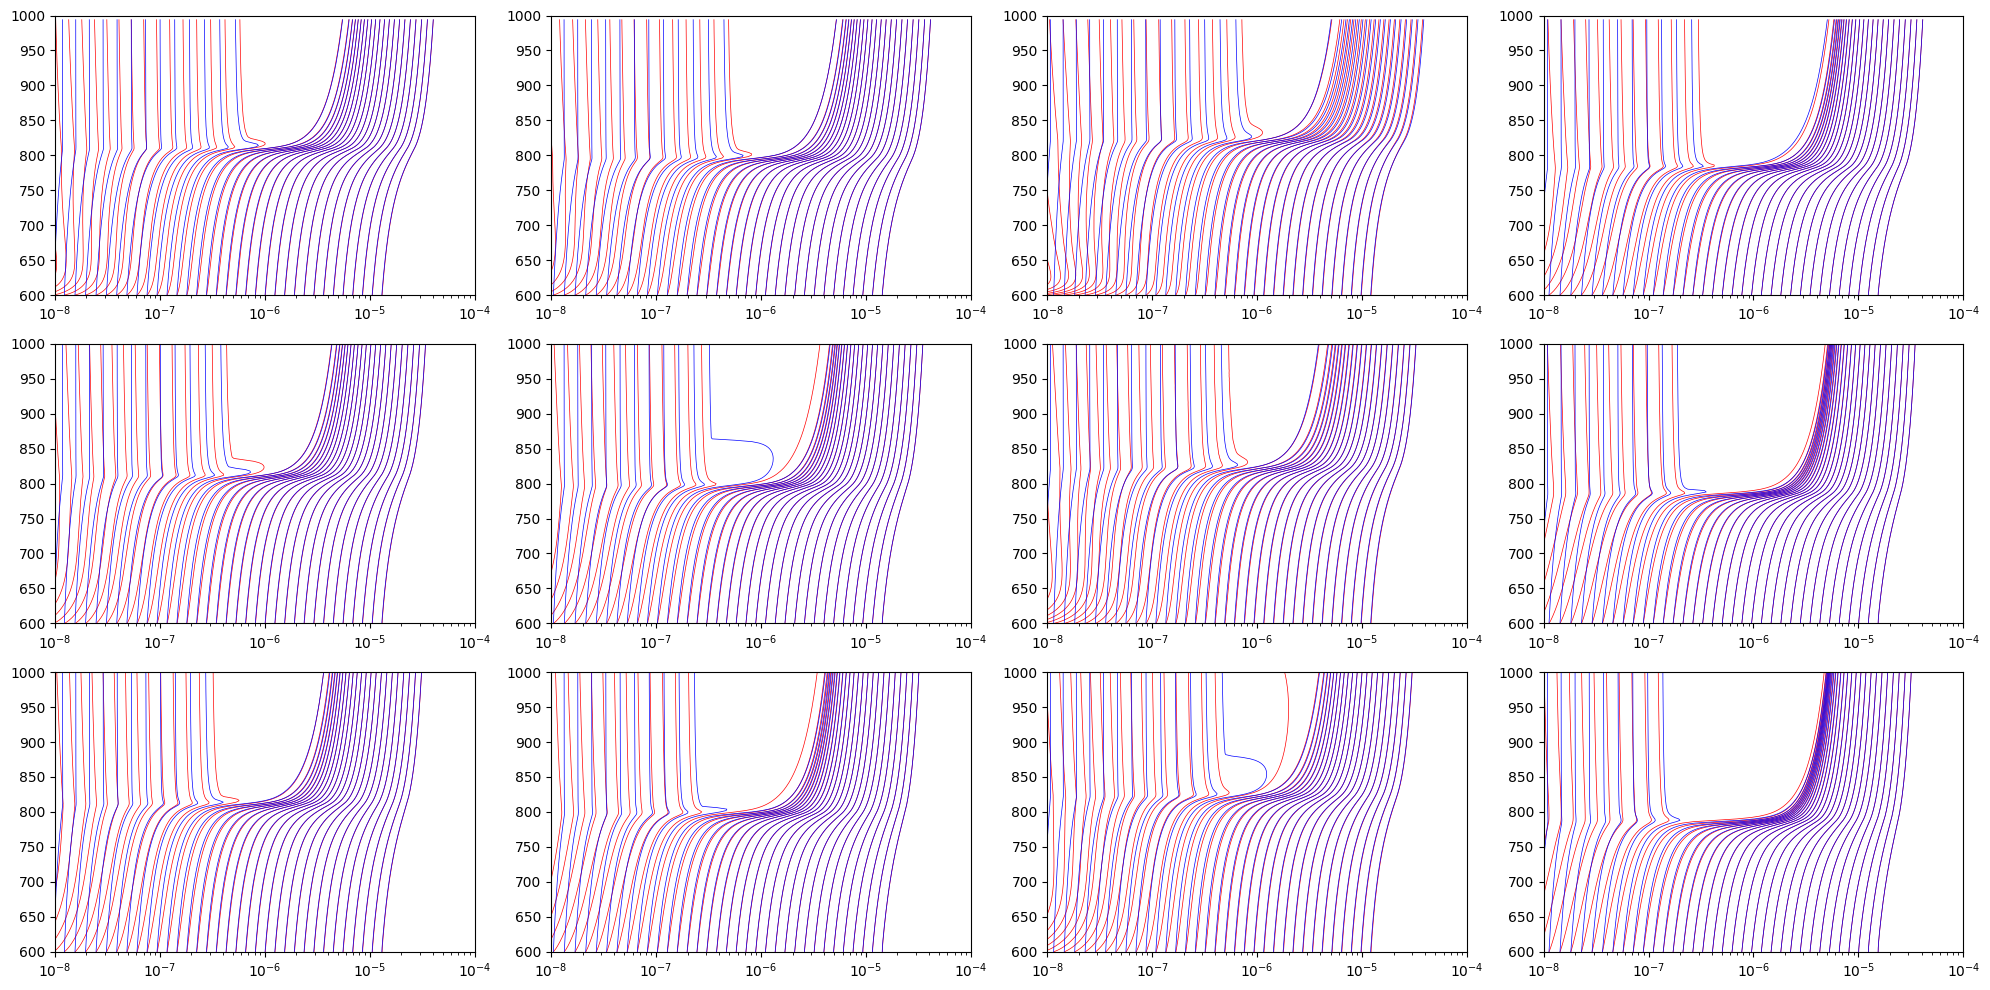

In [20]:
#Sum the bins at time = 0 and then the sum of bins at time right before RH = 100
# at RH = 90 or from initial parameters
fig = plt.figure(figsize = (20,10))
for i in range (0,12):
    plt.subplot(3,4,i+1)
    plt.plot(Name_ls[i+12]['rd'][:,0:None:10,0], Name_ls[i+12]['height'], 'r-', linewidth = .5, label = 'With Co-Condensation')
    plt.xscale('log')
    fig = plt.plot(Name_ls[i]['rd'][:,0:None:10,0], Name_ls[i]['height'],'b-', linewidth = .5, label = 'Without Co-condensation')
    plt.ylim([600,1000])
    plt.xlim([1E-8, 1E-4])
    #plt.legend()

plt.tight_layout()

In [21]:
Activation_radius_delta = []
Activated_radius = []
Activated_radiusCC = []
data = np.random.rand(399) 
Activation_radius_delta = [] 
for n in range(0,12):
    DifferenceIndexNoCC = xr.DataArray(data, dims=["x"], coords={"x": np.arange(399)})
    DifferenceIndexCC = xr.DataArray(data, dims=["x"], coords={"x": np.arange(399)})
    for i in range(0,len(Name_ls[n]['rd'].isel(time_entries = -1, num_aerosols = 0))-1):
        DifferenceIndexCC[i] = np.log10(Name_ls[n+12]['rd'].isel(time_entries = -1, num_aerosols = 0, num_aerosol_bins = i+1))- np.log10(Name_ls[n+12]['rd'].isel(time_entries = -1, num_aerosols = 0, num_aerosol_bins = i))
    max_indCC = int(DifferenceIndexCC.argmax())
    for i in range(0,len(Name_ls[n]['rd'].isel(time_entries = -1, num_aerosols = 0))-1):
        DifferenceIndexNoCC[i] = np.log10(Name_ls[n]['rd'].isel(time_entries = -1, num_aerosols = 0, num_aerosol_bins = i+1))- np.log10(Name_ls[n]['rd'].isel(time_entries = -1, num_aerosols = 0, num_aerosol_bins = i))
    max_indNoCC = int(DifferenceIndexNoCC.argmax())
    Activated_radius.append(np.float64(Name_ls[n]['ra'].isel(time_entries = -1,  num_aerosol_bins = max_indNoCC+1))*2E9)
    Activated_radiusCC.append(np.float64(Name_ls[n+12]['ra'].isel(time_entries = -1,  num_aerosol_bins = max_indCC+1))*2E9)
    Activation_radius_delta.append((np.float64(Name_ls[n+12]['ra'].isel(time_entries = -1,  num_aerosol_bins = max_indNoCC+1))-np.float64(Name_ls[n+12]['ra'].isel(time_entries = -1,  num_aerosol_bins = max_indCC+1)))*2E9)
Data = {'Activation Diameter, No CC ($nm$)':Activated_radius,'Activation Diameter,  CC ($nm$)':Activated_radiusCC, ' $\Delta$D ($nm$)':Activation_radius_delta}
Activation_radius_delta = pd.DataFrame(Data)


<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1646272/4097608181.py:18: SyntaxWarning: invalid escape sequence '\D'
  Data = {'Activation Diameter, No CC ($nm$)':Activated_radius,'Activation Diameter,  CC ($nm$)':Activated_radiusCC, ' $\Delta$D ($nm$)':Activation_radius_delta}


In [22]:
Activated_radius

[np.float64(212.0273434344203),
 np.float64(174.96712605504354),
 np.float64(273.9296799762329),
 np.float64(119.14769117018751),
 np.float64(164.11363079662692),
 np.float64(124.34457265169122),
 np.float64(226.04956544882387),
 np.float64(81.13622616582478),
 np.float64(141.33523429255584),
 np.float64(102.61040941702),
 np.float64(194.67467838811976),
 np.float64(66.95444125855037)]

In [23]:
Activated_radiusCC

[np.float64(207.54929878718698),
 np.float64(171.27179794508717),
 np.float64(262.4810091517297),
 np.float64(114.16800917360587),
 np.float64(164.11363079662692),
 np.float64(119.14769117018751),
 np.float64(216.60200553100083),
 np.float64(74.49590453102621),
 np.float64(138.3502160437893),
 np.float64(96.24531891583946),
 np.float64(190.56312424898383),
 np.float64(60.17642489833283)]

In [24]:
Activation_radius_delta.index = ['Cluster 1 Updraft 1','Cluster 2 Updraft 1','Cluster 3 Updraft 1','Cluster 4 Updraft 1', 'Cluster 1 Updraft 2','Cluster 2 Updraft 2','Cluster 3 Updraft 2','Cluster 4 Updraft 2','Cluster 1 Updraft 3','Cluster 2 Updraft 3','Cluster 3 Updraft 3','Cluster 4 Updraft 3']
Activation_radius_delta

,"Activation Diameter, No CC ($nm$)","Activation Diameter, CC ($nm$)",$\Delta$D ($nm$)
Cluster 1 Updraft 1,212.027343,207.549299,4.478045
Cluster 2 Updraft 1,174.967126,171.271798,3.695328
Cluster 3 Updraft 1,273.929680,262.481009,11.448671
Cluster 4 Updraft 1,119.147691,114.168009,4.979682
Cluster 1 Updraft 2,164.113631,164.113631,0.000000
Cluster 2 Updraft 2,124.344573,119.147691,5.196881
Cluster 3 Updraft 2,226.049565,216.602006,9.447560
Cluster 4 Updraft 2,81.136226,74.495905,6.640322
Cluster 1 Updraft 3,141.335234,138.350216,2.985018
Cluster 2 Updraft 3,102.610409,96.245319,6.365091


In [25]:
n = 2
DifferenceIndexNoCC = xr.DataArray(data, dims=["x"], coords={"x": np.arange(399)})
DifferenceIndexCC = xr.DataArray(data, dims=["x"], coords={"x": np.arange(399)})
for i in range(0,len(Name_ls[n]['rd'].isel(time_entries = -1, num_aerosols = 0))-1):
    DifferenceIndexCC[i] = Name_ls[n+12]['rd'].isel(time_entries = -1, num_aerosols = 0, num_aerosol_bins = i+1)- Name_ls[n+12]['rd'].isel(time_entries = -1, num_aerosols = 0, num_aerosol_bins = i)
Test = int(DifferenceIndexCC.argmax())
for i in range(0,len(Name_ls[n]['rd'].isel(time_entries = -1, num_aerosols = 0))-1):
    DifferenceIndexNoCC[i] = Name_ls[n]['rd'].isel(time_entries = -1, num_aerosols = 0, num_aerosol_bins = i+1)- Name_ls[n]['rd'].isel(time_entries = -1, num_aerosols = 0, num_aerosol_bins = i)
TestNoCC = int(DifferenceIndexNoCC.argmax())


(1e-08, 0.0001)

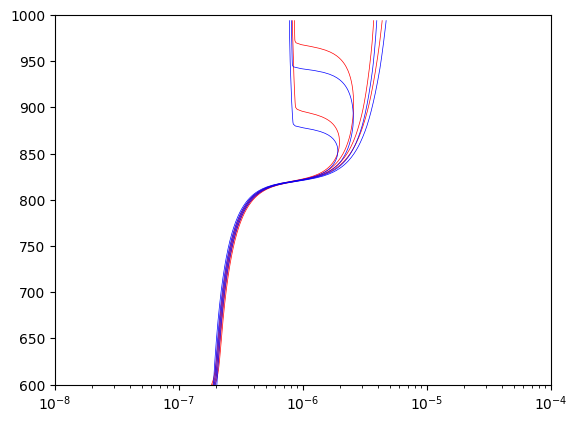

In [26]:
plt.plot(Name_ls[2+12]['rd'][:,Test-1:Test+3,0], Name_ls[2+12]['height'], 'r-', linewidth = .5, label = 'With Co-Condensation')
plt.xscale('log')
fig = plt.plot(Name_ls[2]['rd'][:,TestNoCC-1:TestNoCC+3,0], Name_ls[2]['height'],'b-', linewidth = .5, label = 'Without Co-condensation')
plt.ylim([600,1000])
plt.xlim([1E-8, 1E-4])

In [27]:
dx = np.log10(Name_ls[0]['ra'].isel(time_entries = 0)[1:-1].values/Name_ls[0]['ra'].isel(time_entries = 0)[:-2].values)
deltax = dx[1]

In [28]:
activatednumber = []
activatednumbercc = []
for i in range(12):
    print(i)
    mask = Name_ls[i]['ra'].isel(time_entries = 0, num_aerosol_bins = slice(1,400))>(Activated_radius[i]/2E9)
    activatednumber.append(Name_ls[i]['dNdlogDr'].isel(time_entries = 0, num_aerosols = 0).where(mask.values == True).sum('num_aerosol_bins_minus_1')*deltax)
for i in range(12,24):
    print(i)

    mask = Name_ls[i]['ra'].isel(time_entries = 0, num_aerosol_bins = slice(1,400))>(Activated_radiusCC[i-12]/2E9)
    activatednumbercc.append(Name_ls[i]['dNdlogDr'].isel(time_entries = 0, num_aerosols = 0).where(mask.values == True).sum('num_aerosol_bins_minus_1')*deltax)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


In [29]:
x = np.float64(activatednumber)
y = CDNC_df['NoCC CDNC ($cm^{-3}$)'].values

In [30]:
x_ = np.float64(activatednumbercc)
y_ = CDNC_df['CC CDNC ($cm^{-3}$)'].values


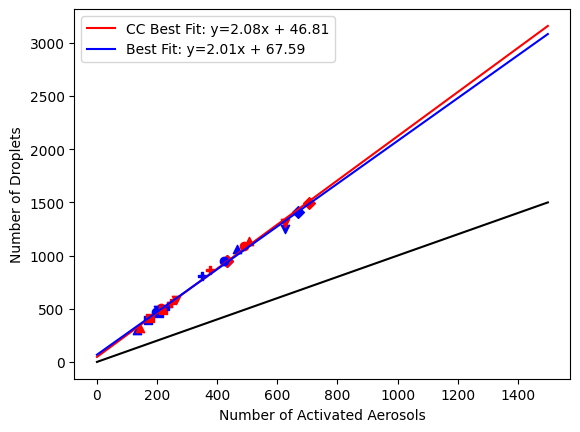

In [31]:
xspace = np.linspace(0, 1500,10)
slopeNoCC, interceptNoCC = np.polyfit(x,y, 1)
slopeCC, interceptCC = np.polyfit(x_[1:],y_[1:], 1)
lineCC = slopeCC * xspace + interceptCC
line = slopeNoCC * xspace + interceptNoCC
markers = ['o', 's', 'v', '^', 'D', 'P']
for i in range(12):
    plt.scatter(x[i],y[i], marker = markers[i % 6], color = 'blue')
    plt.scatter(x_[i],y_[i], marker = markers[i % 6], color = 'red')
plt.plot(xspace, lineCC, 'r-', label=f'CC Best Fit: y={slopeCC:.2f}x + {interceptCC:.2f}')

plt.plot(xspace, line, 'b-', label=f'Best Fit: y={slopeNoCC:.2f}x + {interceptNoCC:.2f}')

plt.xlabel('Number of Activated Aerosols')
plt.ylabel('Number of Droplets')
plt.legend()
plt.plot(xspace, xspace, color ='black', label='x = y')